# MOP 3231 · Week 2 Lab / Task 1 — Data Preprocessing & Cleaning

**Student:** Imamsidikov
**Dataset:** `data/almaty_apartments_raw.csv` (synthetic Almaty apartment listings, generated for the course — not market data)

The notebook is organised in 8 steps:

| # | Step |
|---|------|
| 1 | Project setup & versions |
| 2 | Load and inspect |
| 3 | Clean and transform (duplicates/reposts, districts, text → numbers) |
| 4 | Sentinels, impossible values, outliers → `data/almaty_apartments_clean.csv` |
| 5 | Missing data (split first, diagnose, masking experiment, fill) |
| 6 | Scaling and encoding (+ sanity-check model) |
| 7 | EDA and cleaning log |
| 8 | Summary and git history |

## Step 1 · Project setup

Isolated venv `.Imamsidikov_ML_task1` (Python 3.12), pinned `requirements.txt`, git repository.
Jupyter is only a tool and is not listed in `requirements.txt`.

In [1]:
import sys
import numpy as np
import pandas as pd
import sklearn
import matplotlib

print("Python      ", sys.version.split()[0])
print("NumPy       ", np.__version__)
print("pandas      ", pd.__version__)
print("scikit-learn", sklearn.__version__)
print("matplotlib  ", matplotlib.__version__)

Python       3.12.5
NumPy        2.0.2
pandas       2.3.3
scikit-learn 1.6.1
matplotlib   3.9.4


In [2]:
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)

# the cleaning log: one entry per operation (step, operation, rows before, rows after, cells changed)
LOG = []

def log(step, operation, before, after, cells=0):
    LOG.append({"Step": step, "Operation": operation, "Rows before": before,
                "Rows after": after, "Cells changed": int(cells)})
    print(f"[{step}] {operation}: {before} -> {after} rows, {int(cells)} cells changed")

## Step 2 · Load and inspect

**YOUR_ID = 2954** — the last four digits of my student ID (S24072954), used as `random_state` for the 90 % sample and for the train/test split.

In [3]:
YOUR_ID = 2954

raw = pd.read_csv("data/almaty_apartments_raw.csv")
ids = raw["listing_id"].drop_duplicates().sample(frac=0.9, random_state=YOUR_ID)
df = raw[raw["listing_id"].isin(ids)].reset_index(drop=True)

print("raw file:", raw.shape, "-> my sample:", df.shape)
print(df.dtypes)
print(df.isna().sum())
print(df.describe(include="all").T)

raw file: (1284, 11) -> my sample: (1153, 11)
listing_id           object
listed_date          object
district             object
rooms                object
area_m2              object
floor                 int64
total_floors          int64
year_built          float64
building_type        object
ceiling_height_m    float64
price_kzt            object
dtype: object
listing_id            0
listed_date           0
district              0
rooms                 0
area_m2               0
floor                 0
total_floors          0
year_built           56
building_type         0
ceiling_height_m    144
price_kzt             0
dtype: int64
                   count unique         top freq         mean         std  min     25%     50%     75%     max
listing_id          1153   1080   ALM-10932    3          NaN         NaN  NaN     NaN     NaN     NaN     NaN
listed_date         1153    245  2026-04-18   11          NaN         NaN  NaN     NaN     NaN     NaN     NaN
district            11

### Q1 · Types — raw values of the object columns

In [4]:
for col in ["rooms", "area_m2", "price_kzt", "listed_date"]:
    print(col, df[col].sample(10, random_state=YOUR_ID).tolist())

def non_numeric(s):
    s = s.astype(str)
    return s[~s.str.fullmatch(r"-?\d+(\.\d+)?")]

for col in ["rooms", "area_m2", "price_kzt"]:
    bad = non_numeric(df[col])
    print(f"\n{col}: {len(bad)} non-numeric values, e.g.", bad.drop_duplicates().head(6).tolist())

rooms ['1', '1', '1', '4', '3', '3', '2', '3', '1', '3']
area_m2 ['38.6', '33.8', '28.8', '76.8', '71.8', '81.9', '69.7', '72.9', '38.3', '75.9']
price_kzt ['20280000', '15,690,000', '17480000', '32090000', '54240000', '59,440,000', '49580000', '62340000', '21840000', '43940000']
listed_date ['2026-06-06', '2026-06-03', '2026-04-25', '2026-06-22', '2026-03-20', '2026-06-17', '2026-01-24', '2026-03-04', '2026-08-02', '2026-03-08']

rooms: 31 non-numeric values, e.g. ['studio']

area_m2: 95 non-numeric values, e.g. ['59,4', '40,8', '62,2', '61.1 m²', '40.8 m²', '43.4 m²']

price_kzt: 93 non-numeric values, e.g. ['41,560,000', '29 060 000 ₸', '52,760,000', '31,620,000', '70,860,000', '32 620 000 ₸']


**Object columns that should be numbers or dates**

| Column | Why pandas did not parse it |
|---|---|
| `rooms` | contains the word `"studio"` next to the digits, so the whole column is text |
| `area_m2` | some values use a decimal **comma** (`"62,2"`) and some carry a unit suffix (`"61.1 m²"`) |
| `price_kzt` | thousands separators — commas (`"41,560,000"`) or spaces plus the currency sign (`"82 080 000 ₸"`) |
| `listed_date` | CSV has no date type; `read_csv` leaves `YYYY-MM-DD` strings as object unless told to parse them |

(`district`, `building_type`, `listing_id` are object on purpose — they are text/categorical.)
`year_built` and `ceiling_height_m` are `float64` rather than int only because they contain NaN.

### Q2 · Grain — exact duplicates and reposts

In [5]:
n_exact = df.duplicated().sum()
n_repost = df.drop_duplicates()["listing_id"].duplicated().sum()
print("(a) exact copies of another row:              ", n_exact)
print("(b) not exact copies but share a listing_id:  ", n_repost)

dedup = df.drop_duplicates()
reposts = dedup[dedup["listing_id"].duplicated(keep=False)].sort_values(["listing_id", "listed_date"])
two_ids = reposts["listing_id"].unique()[:2]
print(reposts[reposts["listing_id"].isin(two_ids)])

differs = {c: int((reposts.groupby("listing_id")[c].nunique() > 1).sum()) for c in df.columns if c != "listing_id"}
print("\nnumber of repost groups in which each column differs:", differs)

(a) exact copies of another row:               33
(b) not exact copies but share a listing_id:   40
    listing_id listed_date   district rooms area_m2  floor  total_floors  year_built building_type  ceiling_height_m price_kzt
968  ALM-10003  2026-05-04     Auezov     2    48.6      2             5      1978.0         panel              2.55  28320000
8    ALM-10003  2026-05-29     Auezov     2    48.6      2             5      1978.0         panel              2.55  26120000
940  ALM-10009  2025-12-03  Medeuskiy     1    33.4      2             9      1992.0         brick              3.19  42700000
176  ALM-10009  2026-01-19  Medeuskiy     1    33.4      2             9      1992.0         brick              3.19  39400000

number of repost groups in which each column differs: {'listed_date': 40, 'district': 0, 'rooms': 0, 'area_m2': 0, 'floor': 0, 'total_floors': 0, 'year_built': 0, 'building_type': 0, 'ceiling_height_m': 0, 'price_kzt': 40}


Within every repost pair **only `listed_date` and `price_kzt` differ** — the flat itself (district, rooms, area, floors, year, type, ceiling) is identical.
It is the same apartment posted again at a new asking price.

**Grain of the cleaned table:** *one row = one apartment listing (one unique `listing_id`) with its current asking price.*

### Q3 · Validation spec

| Column | Target type | Valid values |
|---|---|---|
| `listing_id` | string | `ALM-#####`, unique after cleaning |
| `listed_date` | datetime | 2025-11-01 … 2026-09-30 (the data window), not in the future |
| `district` | category | exactly one of the 8: Alatau, Almaly, Auezov, Bostandyk, Medeu, Nauryzbay, Turksib, Zhetysu |
| `rooms` | int | 1 – 6 (studio = 1) |
| `area_m2` | float | 20 – 250 m², and plausible for the room count (≈ 25–60 m² per room) |
| `floor` | int | 1 – `total_floors` (**two-column rule: `floor ≤ total_floors`**) |
| `total_floors` | int | 1 – 40 |
| `year_built` | int | 1930 – 2026 |
| `building_type` | category | panel / brick / monolith |
| `ceiling_height_m` | float | 2.4 – 4.0 m |
| `price_kzt` | int | > 0; 5 M – 500 M ₸; price per m² consistent with the district |

## Step 3 · Clean and transform

Only row-level rules here — nothing is learned from the data, so this is safe before the split.

### 3a · Exact duplicates and reposts

In [6]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
log("3a", "drop exact duplicate rows", before, len(df), (before - len(df)) * df.shape[1])

df["listed_date"] = pd.to_datetime(df["listed_date"], format="%Y-%m-%d", errors="raise")
log("3a", "parse listed_date to datetime", len(df), len(df), len(df))

pairs = df[df["listing_id"].duplicated(keep=False)].sort_values(["listing_id", "listed_date"])
first, last = pairs.groupby("listing_id").first(), pairs.groupby("listing_id").last()
change = (last["price_kzt"].str.replace(r"\D", "", regex=True).astype(int)
          / first["price_kzt"].str.replace(r"\D", "", regex=True).astype(int) - 1)
print("repost groups:", pairs["listing_id"].nunique())
print("days between postings:", (last["listed_date"] - first["listed_date"]).dt.days.describe().round(1).to_dict())
print("price change of the later posting vs the earlier one:", change.describe().round(3).to_dict())

before = len(df)
df = df.sort_values("listed_date").drop_duplicates("listing_id", keep="last").sort_index().reset_index(drop=True)
log("3a", "resolve reposts: keep the latest posting per listing_id", before, len(df), (before - len(df)) * df.shape[1])
assert df["listing_id"].is_unique

[3a] drop exact duplicate rows: 1153 -> 1120 rows, 363 cells changed
[3a] parse listed_date to datetime: 1120 -> 1120 rows, 1120 cells changed
repost groups: 40
days between postings: {'count': 40.0, 'mean': 31.0, 'std': 16.7, 'min': 7.0, '25%': 14.8, '50%': 32.0, '75%': 46.2, 'max': 58.0}
price change of the later posting vs the earlier one: {'count': 40.0, 'mean': -0.063, 'std': 0.017, 'min': -0.086, '25%': -0.078, '50%': -0.066, '75%': -0.047, 'max': -0.03}
[3a] resolve reposts: keep the latest posting per listing_id: 1120 -> 1080 rows, 440 cells changed


**Which posting is valid?** The **latest** one (by `listed_date`, not by file order). A repost supersedes the earlier
advertisement: the seller re-listed the same flat, and in every pair the later price is *lower* (the numbers above), i.e. a price cut.
The most recent asking price is the one currently on offer, so it is the right target; the earlier price is stale.

### 3b · Districts

In [7]:
print(df["district"].value_counts().to_string())

district
Medeu            134
Turksib          127
Zhetysu          119
Bostandyk        118
Almaly           111
Auezov           111
Alatau           103
Nauryzbay        100
turksib            9
 Auezov            7
medeu              7
AUEZOV             7
auezov             7
Наурызбайский      7
bostandyk          7
Auezovskiy         6
Nauryzbayskiy      5
BOSTANDYK          5
 Turksib           5
Almalinskiy        5
 Zhetysu           5
ALMALY             4
Alatauskiy         4
 Bostandyk         4
nauryzbay          4
ZHETYSU            4
 Almaly            4
Медеуский          4
TURKSIB            4
 Alatau            4
NAURYZBAY          4
 Medeu             4
MEDEU              4
Zhetysuskiy        3
almaly             3
Bostandykskiy      3
 Nauryzbay         2
zhetysu            2
Medeuskiy          2
Ауэзовский         2
ALATAU             2
Турксибский        2
Бостандыкский      2
alatau             1
Turksibskiy        1
Алатауский         1
Алмалинский        1


In [8]:
key = df["district"].str.strip().str.casefold().str[:4]
DISTRICT_MAP = {
    "alat": "Alatau",    "алат": "Alatau",
    "alma": "Almaly",    "алма": "Almaly",
    "auez": "Auezov",    "ауэз": "Auezov",
    "bost": "Bostandyk", "бост": "Bostandyk",
    "mede": "Medeu",     "меде": "Medeu",
    "naur": "Nauryzbay", "наур": "Nauryzbay",
    "turk": "Turksib",   "турк": "Turksib",
    "zhet": "Zhetysu",   "жеты": "Zhetysu",
}
mapped = key.map(DISTRICT_MAP)
print("unmapped spellings:", df.loc[mapped.isna(), "district"].unique())
changed = (mapped != df["district"]).sum()
df["district"] = mapped
log("3b", "canonicalise district spellings (strip, casefold, Latin/Cyrillic prefix map)", len(df), len(df), changed)

print("nunique:", df["district"].nunique(), "| NaN:", df["district"].isna().sum())
assert df["district"].nunique() == 8 and df["district"].isna().sum() == 0

unmapped spellings: []
[3b] canonicalise district spellings (strip, casefold, Latin/Cyrillic prefix map): 1080 -> 1080 rows, 157 cells changed
nunique: 8 | NaN: 0


Spelling variants found: leading/trailing spaces (`" Auezov"`), case (`"MEDEU"`, `"medeu"`), the Russian adjectival
form in Latin (`"Medeuskiy"`, `"Almalinskiy"`) and in Cyrillic (`"Медеуский"`, `"Наурызбайский"`). The first four letters of the
stripped, case-folded name identify each district uniquely in both alphabets, so a 16-key map covers everything — no NaN produced.

### 3c · Text that should be numbers

The same character means different things per column:
* in `area_m2` a **comma is a decimal separator** (`"62,2"` = 62.2 m²) → replace it with a dot and strip `m²`;
* in `price_kzt` a **comma (or space) is a thousands separator** (`"41,560,000"`) → keep digits only;
* `rooms`: **`"studio"` is treated as 1 room** (a studio is a single living room).

In [9]:
def to_number(raw_col, cleaned):
    parsed = pd.to_numeric(cleaned, errors="coerce")
    new_nan = parsed.isna() & raw_col.notna()
    print(f"{raw_col.name}: NaN created by parsing = {new_nan.sum()}")
    assert new_nan.sum() == 0, raw_col[new_nan].unique()
    return parsed

area_text = df["area_m2"].astype(str)
area_clean = area_text.str.replace("m²", "", regex=False).str.strip().str.replace(",", ".", regex=False)
new_area = to_number(df["area_m2"], area_clean)
log("3c", "area_m2: strip 'm²', decimal comma -> dot, to float", len(df), len(df), (area_text != area_clean).sum())
df["area_m2"] = new_area

price_text = df["price_kzt"].astype(str)
price_clean = price_text.str.replace(r"\D", "", regex=True)
new_price = to_number(df["price_kzt"], price_clean).astype("int64")
log("3c", "price_kzt: keep digits only (drop ',', spaces, '₸'), to int", len(df), len(df), (price_text != price_clean).sum())
df["price_kzt"] = new_price

n_studio = (df["rooms"] == "studio").sum()
df["rooms"] = to_number(df["rooms"], df["rooms"].replace("studio", "1")).astype("int64")
log("3c", "rooms: 'studio' -> 1, to int", len(df), len(df), n_studio)

print(df[["rooms", "area_m2", "price_kzt"]].describe().round(1))

area_m2: NaN created by parsing = 0
[3c] area_m2: strip 'm²', decimal comma -> dot, to float: 1080 -> 1080 rows, 88 cells changed
price_kzt: NaN created by parsing = 0
[3c] price_kzt: keep digits only (drop ',', spaces, '₸'), to int: 1080 -> 1080 rows, 90 cells changed
rooms: NaN created by parsing = 0
[3c] rooms: 'studio' -> 1, to int: 1080 -> 1080 rows, 28 cells changed
        rooms  area_m2    price_kzt
count  1080.0   1080.0       1080.0
mean      2.3     68.7   46099796.3
std       1.0     56.4   24687118.5
min       1.0     25.3   11440000.0
25%       2.0     45.2   28090000.0
50%       2.0     58.8   40025000.0
75%       3.0     79.0   57287500.0
max       5.0    736.0  183190000.0


In [10]:
print(pd.DataFrame(LOG).to_string(index=False))
print("\nreposts resolved:", n_repost, "| districts:", df["district"].nunique())
print(df.dtypes)

Step                                                                    Operation  Rows before  Rows after  Cells changed
  3a                                                    drop exact duplicate rows         1153        1120            363
  3a                                                parse listed_date to datetime         1120        1120           1120
  3a                      resolve reposts: keep the latest posting per listing_id         1120        1080            440
  3b canonicalise district spellings (strip, casefold, Latin/Cyrillic prefix map)         1080        1080            157
  3c                          area_m2: strip 'm²', decimal comma -> dot, to float         1080        1080             88
  3c                  price_kzt: keep digits only (drop ',', spaces, '₸'), to int         1080        1080             90
  3c                                                 rooms: 'studio' -> 1, to int         1080        1080             28

reposts resolved: 40 | 

## Step 4 · Sentinels, impossible values, outliers
### Sentinels

In [11]:
print(df[["floor", "total_floors", "year_built", "ceiling_height_m", "rooms", "area_m2", "price_kzt"]].describe().T)
for col in ["floor", "year_built", "ceiling_height_m"]:
    print(f"\n{col} — smallest values:", df[col].value_counts().sort_index().head(4).to_dict())

                   count          mean           std         min           25%          50%           75%          max
floor             1080.0  5.910185e+00  4.818512e+00        -1.0  2.000000e+00         5.00  8.000000e+00         30.0
total_floors      1080.0  1.041852e+01  6.160717e+00         3.0  5.000000e+00         9.00  1.200000e+01         25.0
year_built        1026.0  1.943307e+03  3.015691e+02         0.0  1.972000e+03      1986.00  2.009000e+03       2024.0
ceiling_height_m   946.0  2.716078e+00  4.540510e-01         0.0  2.620000e+00         2.77  2.910000e+00          3.2
rooms             1080.0  2.270370e+00  1.004647e+00         1.0  2.000000e+00         2.00  3.000000e+00          5.0
area_m2           1080.0  6.872361e+01  5.636624e+01        25.3  4.517500e+01        58.85  7.902500e+01        736.0
price_kzt         1080.0  4.609980e+07  2.468712e+07  11440000.0  2.809000e+07  40025000.00  5.728750e+07  183190000.0

floor — smallest values: {-1: 12, 1: 140, 2: 12

In [12]:
SENTINELS = {"floor": -1, "year_built": 0, "ceiling_height_m": 0}
sentinel_counts = {}
for col, value in SENTINELS.items():
    mask = df[col] == value
    sentinel_counts[col] = int(mask.sum())
    df.loc[mask, col] = np.nan
    log("4", f"{col}: sentinel {value} -> NaN", len(df), len(df), mask.sum())
print(sentinel_counts)

[4] floor: sentinel -1 -> NaN: 1080 -> 1080 rows, 12 cells changed
[4] year_built: sentinel 0 -> NaN: 1080 -> 1080 rows, 24 cells changed
[4] ceiling_height_m: sentinel 0 -> NaN: 1080 -> 1080 rows, 22 cells changed
{'floor': 12, 'year_built': 24, 'ceiling_height_m': 22}


`floor = -1`, `year_built = 0` and `ceiling_height_m = 0` are placeholders for "unknown", not measurements (a 0 m ceiling or a year-0 building
cannot exist; the lowest real floor is 1). They become NaN — the rows are kept because every other column in them is fine.

### Impossible values

In [13]:
spec_checks = {
    "floor > total_floors": df["floor"] > df["total_floors"],
    "floor < 1": df["floor"] < 1,
    "total_floors outside 1-40": ~df["total_floors"].between(1, 40),
    "year_built outside 1930-2026": df["year_built"].notna() & ~df["year_built"].between(1930, 2026),
    "ceiling outside 2.4-4.0 m": df["ceiling_height_m"].notna() & ~df["ceiling_height_m"].between(2.4, 4.0),
    "rooms outside 1-6": ~df["rooms"].between(1, 6),
    "area outside 20-250 m²": ~df["area_m2"].between(20, 250),
    "price <= 0": df["price_kzt"] <= 0,
    "listed_date in the future": df["listed_date"] > pd.Timestamp("2026-09-30"),
}
print(pd.Series({k: int(v.sum()) for k, v in spec_checks.items()}).to_string())
print(df.loc[spec_checks["floor > total_floors"], ["listing_id", "floor", "total_floors", "building_type", "year_built"]])

floor > total_floors            12
floor < 1                        0
total_floors outside 1-40        0
year_built outside 1930-2026     0
ceiling outside 2.4-4.0 m        0
rooms outside 1-6                0
area outside 20-250 m²          11
price <= 0                       0
listed_date in the future        0
     listing_id  floor  total_floors building_type  year_built
115   ALM-10881    8.0             5         panel      1962.0
196   ALM-10074   11.0             9      monolith      2018.0
225   ALM-10420   11.0             9         panel      1987.0
266   ALM-10266   13.0            12         panel      1962.0
624   ALM-10044   30.0            25      monolith      2022.0
640   ALM-10628    6.0             5         brick      1964.0
691   ALM-10695   14.0            12         panel      1972.0
703   ALM-10851   13.0            12         panel      1988.0
747   ALM-10321   10.0             5         panel      1968.0
806   ALM-10729   15.0            12         panel     

In [14]:
bad_floor = df["floor"] > df["total_floors"]
print("total_floors values in the data:", sorted(df["total_floors"].unique()))
df.loc[bad_floor, "floor"] = np.nan
log("4", "floor > total_floors -> floor set to NaN (imputed in Step 5)", len(df), len(df), bad_floor.sum())

total_floors values in the data: [np.int64(3), np.int64(4), np.int64(5), np.int64(9), np.int64(12), np.int64(16), np.int64(20), np.int64(25)]
[4] floor > total_floors -> floor set to NaN (imputed in Step 5): 1080 -> 1080 rows, 12 cells changed


**Rule `floor ≤ total_floors`** (two columns). We cannot know which of the two is wrong, but `total_floors` only takes a few
standard building heights (3, 4, 5, 9, 12, 16, 20, 25 — typical Soviet panel / modern monolith storeys) and is consistent with the building type,
whereas `floor` is a free per-flat number. So the more likely error is in `floor`: I set **`floor` to NaN** and keep the row (price, area, district are still good);
Step 5 imputes it from the training data. Dropping would lose otherwise valid rows for a feature that is not the target.

The rows with `area_m2` outside 20–250 m² are dealt with in the outlier section below, where the price-per-m² check shows what went wrong with them.

### Outliers — IQR fences on price per m²

In [15]:
df["price_per_m2"] = df["price_kzt"] / df["area_m2"]
df["area_before_fix"] = df["area_m2"]

def fences(values, groups=None):
    grouped = values if groups is None else values.groupby(groups)
    q1, q3 = grouped.quantile(0.25), grouped.quantile(0.75)
    if groups is not None:
        q1, q3 = groups.map(q1), groups.map(q3)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

low, high = fences(df["price_per_m2"])
flag_global = (df["price_per_m2"] < low) | (df["price_per_m2"] > high)
print(f"global fences: [{low:,.0f}, {high:,.0f}] ₸/m²  -> flagged: {flag_global.sum()}")

low_g, high_g = fences(df["price_per_m2"], df["district"])
flag_district = (df["price_per_m2"] < low_g) | (df["price_per_m2"] > high_g)
print("fences by district -> flagged:", flag_district.sum())
print(df.groupby("district")["price_per_m2"].median().round(0).sort_values())

global fences: [-85,522, 1,513,507] ₸/m²  -> flagged: 0
fences by district -> flagged: 11
district
Alatau        467442.0
Nauryzbay     470729.0
Turksib       513110.0
Zhetysu       618361.0
Auezov        653278.0
Almaly        874327.0
Bostandyk     958969.0
Medeu        1065021.0
Name: price_per_m2, dtype: float64


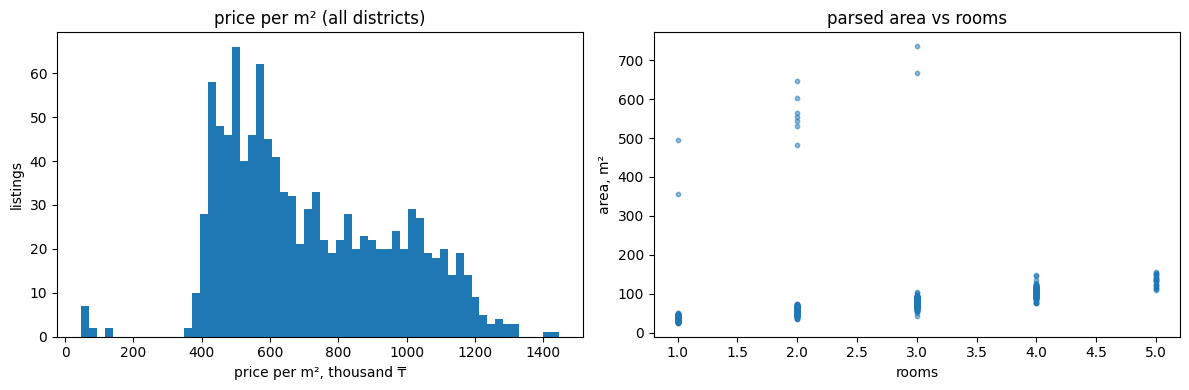

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["price_per_m2"] / 1000, bins=60)
axes[0].set_xlabel("price per m², thousand ₸"); axes[0].set_ylabel("listings"); axes[0].set_title("price per m² (all districts)")
axes[1].scatter(df["rooms"], df["area_m2"], s=10, alpha=0.5)
axes[1].set_xlabel("rooms"); axes[1].set_ylabel("area, m²"); axes[1].set_title("parsed area vs rooms")
plt.tight_layout(); plt.show()

The **global** fence flags almost nothing although the histogram has a separate cluster far to the left: district price levels differ
roughly 2× (Alatau/Nauryzbay ≈ 470 k ₸/m² vs Medeu/Bostandyk ≈ 1 M ₸/m²), so the global IQR is very wide and the global lower fence
falls below zero — a value that is absurd *for its district* still sits inside it. Grouping **by `district`** compares each flat with
its own market, so the fences become tight enough to catch the bad rows.

In [17]:
flagged = df.loc[flag_district, ["listing_id", "district", "rooms", "area_m2", "price_kzt", "price_per_m2", "building_type"]].copy()
flagged["district_median_ppm"] = flagged["district"].map(df.groupby("district")["price_per_m2"].median()).round(0)
print(flagged.sort_values("area_m2").to_string())

     listing_id   district  rooms  area_m2  price_kzt   price_per_m2 building_type  district_median_ppm
539   ALM-10405    Turksib      1    356.0   18830000   52893.258427         brick             513110.0
170   ALM-10069    Zhetysu      2    481.0   27710000   57609.147609         brick             618361.0
45    ALM-10264  Bostandyk      1    495.0   42680000   86222.222222         panel             958969.0
294   ALM-10072      Medeu      2    530.0   64270000  121264.150943      monolith            1065021.0
567   ALM-10659    Turksib      2    544.0   25030000   46011.029412         brick             513110.0
907   ALM-10058  Bostandyk      2    555.0   66270000  119405.405405      monolith             958969.0
852   ALM-10909     Alatau      2    565.0   32610000   57716.814159      monolith             467442.0
929   ALM-10276    Turksib      2    604.0   33630000   55678.807947      monolith             513110.0
1002  ALM-11122    Zhetysu      2    647.0   40670000   62859.35

In [18]:
decimal_lost = flag_district & (df["area_m2"] > 250)
typical_per_room = df.loc[~decimal_lost].groupby("rooms")["area_m2"].median()
check = df.loc[decimal_lost, ["listing_id", "rooms", "area_m2", "district", "price_kzt"]].copy()
check["area / 10"] = check["area_m2"] / 10
check["median area for the room count"] = check["rooms"].map(typical_per_room)
check["ppm after fix"] = (check["price_kzt"] / check["area / 10"]).round(0)
check["district median ppm"] = check["district"].map(df.loc[~decimal_lost].groupby("district")["price_per_m2"].median()).round(0)
print(check.to_string())

df.loc[decimal_lost, "area_m2"] = df.loc[decimal_lost, "area_m2"] / 10
df["price_per_m2"] = df["price_kzt"] / df["area_m2"]
log("4", "area_m2 with lost decimal point (> 250 m², ppm outlier) divided by 10", len(df), len(df), decimal_lost.sum())

low_g, high_g = fences(df["price_per_m2"], df["district"])
flag_after = (df["price_per_m2"] < low_g) | (df["price_per_m2"] > high_g)
print("\nflagged after the fix:", flag_after.sum())
print(df.loc[flag_after, ["listing_id", "district", "rooms", "area_m2", "year_built", "building_type", "price_kzt", "price_per_m2"]])

     listing_id  rooms  area_m2   district  price_kzt  area / 10  median area for the room count  ppm after fix  district median ppm
45    ALM-10264      1    495.0  Bostandyk   42680000       49.5                           37.75       862222.0             961168.0
170   ALM-10069      2    481.0    Zhetysu   27710000       48.1                           56.20       576091.0             621237.0
294   ALM-10072      2    530.0      Medeu   64270000       53.0                           56.20      1212642.0            1067103.0
539   ALM-10405      1    356.0    Turksib   18830000       35.6                           37.75       528933.0             515401.0
567   ALM-10659      2    544.0    Turksib   25030000       54.4                           56.20       460110.0             515401.0
712   ALM-10921      3    668.0    Zhetysu   38560000       66.8                           78.60       577246.0             621237.0
847   ALM-10910      3    736.0    Zhetysu   54050000       73.6     

In [19]:
still = df.loc[flag_after]
if still.empty:
    print("no row is outside the per-district fences after the correction")
for _, row in still.iterrows():
    peers = df[(df["district"] == row["district"]) & (df["building_type"] == row["building_type"]) & (df.index != row.name)]
    print(f"{row['listing_id']}: {row['price_per_m2']:,.0f} ₸/m²; {row['district']} {row['building_type']} peers: "
          f"median {peers['price_per_m2'].median():,.0f}, 95th pct {peers['price_per_m2'].quantile(0.95):,.0f}, max {peers['price_per_m2'].max():,.0f}")

no row is outside the per-district fences after the correction


**Decisions per kind of flagged row**

The per-district fences flag **11 rows**, and looking at them shows they are all the same kind:

1. **Area with a lost decimal point (356–736 m² for 1–3-room flats) → correct, divide by 10.** A 1–3-room flat cannot be 356–736 m²
   (every other 1–3-room flat is 25–104 m²), and their price per m² is 8–11× below their district's median. The written value is
   exactly 10× a normal area (e.g. `736.0` → 73.6 m²), i.e. the decimal point was dropped. After dividing by 10 each area matches the typical
   size for its room count (table above: 35.6–73.6 m² vs medians 37.8 / 56.2 / 78.6 m²) and its price per m² lands at its district's level —
   the row becomes consistent with its neighbours. Correcting keeps 11 otherwise valid rows (price, district, floors are fine) that dropping would lose.
2. **After the correction, 0 rows remain outside the per-district fences**, so there is no second kind to decide on. Had a flat with a
   high-but-plausible price per m² (e.g. a premium new monolith) been flagged, I would keep it: being outside a fence alone does not make a
   real asking price wrong, and removing it would bias the target.

`area_before_fix` keeps the parsed-but-uncorrected area for Step 6a.

In [20]:
df.to_csv("data/almaty_apartments_clean.csv", index=False)
print("saved data/almaty_apartments_clean.csv", df.shape)
print(df.isna().sum())

saved data/almaty_apartments_clean.csv (1080, 13)
listing_id            0
listed_date           0
district              0
rooms                 0
area_m2               0
floor                24
total_floors          0
year_built           78
building_type         0
ceiling_height_m    156
price_kzt             0
price_per_m2          0
area_before_fix       0
dtype: int64


## Step 5 · Missing data
### 5a · Split first
Everything learned from the data from now on (medians, means, std, min/max) is fit on **train only**.

In [21]:
from sklearn.model_selection import train_test_split

NUMERIC = ["rooms", "area_m2", "floor", "total_floors", "year_built", "ceiling_height_m"]

train, test = train_test_split(df, test_size=0.2, random_state=YOUR_ID)
train, test = train.copy(), test.copy()
print(train.shape, test.shape)
missing_table = pd.DataFrame({"train NaN": train[NUMERIC].isna().sum(), "train %": (train[NUMERIC].isna().mean() * 100).round(1),
                              "test NaN": test[NUMERIC].isna().sum()})
print(missing_table)

(864, 13) (216, 13)
                  train NaN  train %  test NaN
rooms                     0      0.0         0
area_m2                   0      0.0         0
floor                    21      2.4         3
total_floors              0      0.0         0
year_built               60      6.9        18
ceiling_height_m        120     13.9        36


### 5b · Diagnose the mechanism (train only)

In [22]:
top2 = train[NUMERIC].isna().sum().sort_values(ascending=False).index[:2].tolist()
print("two columns with most missing values:", top2)
rates = pd.DataFrame({col: train.assign(missing=train[col].isna()).groupby("building_type")["missing"].mean()
                      for col in top2 + ["floor"]}).round(3)
rates.loc["overall"] = train[top2 + ["floor"]].isna().mean().round(3)
print(rates)
rows_dropped = len(train) - len(train.dropna(subset=NUMERIC))
for col in top2:
    r = rates.loc[["brick", "monolith", "panel"], col]
    print(f"{col}: missing rate {r.min():.1%} ({r.idxmin()}) .. {r.max():.1%} ({r.idxmax()}), ratio {r.max() / r.min():.1f}x")
print(f"\ndropna() would remove {rows_dropped} of {len(train)} training rows ({rows_dropped / len(train):.1%})")

two columns with most missing values: ['ceiling_height_m', 'year_built']
               ceiling_height_m  year_built  floor
building_type                                     
brick                     0.131       0.077  0.018
monolith                  0.034       0.072  0.024
panel                     0.231       0.063  0.028
overall                   0.139       0.069  0.024
ceiling_height_m: missing rate 3.4% (monolith) .. 23.1% (panel), ratio 6.8x
year_built: missing rate 6.3% (panel) .. 7.7% (brick), ratio 1.2x

dropna() would remove 190 of 864 training rows (22.0%)


In [23]:
for col in top2:
    print(col, "by building_type (median of the known values):",
          train.groupby("building_type")[col].median().to_dict())

ceiling_height_m by building_type (median of the known values): {'brick': 2.93, 'monolith': 2.85, 'panel': 2.5949999999999998}
year_built by building_type (median of the known values): {'brick': 1979.0, 'monolith': 2015.0, 'panel': 1977.0}


**Verdicts** (numbers from the table above, seed 2954):

* **`ceiling_height_m` → MAR.** Missing in 23.1 % of panel, 13.1 % of brick but only 3.4 % of monolith flats (6.8× range).
  Whether it is missing clearly depends on an observed column, and the value itself also depends on building type
  (median 2.59 m panel vs 2.85–2.93 m monolith/brick), so dropping or one global fill would bias it.
* **`year_built` → close to MCAR.** Missing in 7.7 % brick, 7.2 % monolith, 6.3 % panel (only 1.2× range on 60 missing values) — compatible with chance.
  Dropping would not bias it much, but the *value* is strongly tied to building type (median 1977 panel, 1979 brick, 2015 monolith),
  so a per-type fill is still more accurate (5c).
* `floor` (1.8–2.8 % everywhere) → MCAR.

`dropna()` on the numeric columns would remove **190 of 864 training rows (22.0 %)** — too much data to throw away.

### 5c · Masking experiment

In [24]:
from sklearn.metrics import mean_absolute_error

mae = {}
for col in ["ceiling_height_m", "year_built"]:
    known = train[train[col].notna()]
    hidden = known.sample(frac=0.15, random_state=YOUR_ID).index
    rest = train.drop(index=hidden)                    # all an imputer may see
    answers = train.loc[hidden, col]                   # values to recover

    global_pred = pd.Series(rest[col].median(), index=hidden)
    group_med = rest.groupby("building_type")[col].median()
    group_pred = train.loc[hidden, "building_type"].map(group_med)

    mae[col] = {"hidden": len(hidden),
                "global median MAE": mean_absolute_error(answers, global_pred),
                "median by building_type MAE": mean_absolute_error(answers, group_pred)}
print(pd.DataFrame(mae).T.round(4))

                  hidden  global median MAE  median by building_type MAE
ceiling_height_m   112.0             0.1486                       0.0717
year_built         121.0            17.7190                       8.3884


**Result:** ceiling height MAE 0.149 m (global median) vs **0.072 m** (median by building type); year built MAE 17.7 years vs **8.4 years**.
The per-`building_type` median wins for both columns and halves the error — knowing the building type tells you a lot about the missing value.

### 5d · Fill (fit on train, apply to train and test)

| Column | Strategy | Reason |
|---|---|---|
| `ceiling_height_m` | median by `building_type` | MAR on building type; won the masking experiment (0.072 vs 0.149 m MAE) |
| `year_built` | median by `building_type` | near-MCAR, but the value depends on type; won the masking experiment (8.4 vs 17.7 yr MAE) |
| `floor` | global median of train, capped at `total_floors` | few, MCAR-like NaNs; the cap keeps `floor ≤ total_floors` valid |

In [25]:
fill_values = {}
for col in ["ceiling_height_m", "year_built"]:
    med = train.groupby("building_type")[col].median()          # learned on TRAIN only
    fill_values[col] = med.to_dict()
    for frame in (train, test):
        frame[col] = frame[col].fillna(frame["building_type"].map(med))

floor_median = train["floor"].median()                          # learned on TRAIN only
fill_values["floor"] = floor_median
for frame in (train, test):
    frame["floor"] = frame["floor"].fillna(np.minimum(floor_median, frame["total_floors"]))

print("fill values (from train):", fill_values)
n_filled = int(df[NUMERIC].isna().sum().sum())
log("5", "impute year_built, ceiling_height_m (by building_type), floor (median) — fit on train", len(df), len(df), n_filled)

print("NaN left in train:", int(train[NUMERIC].isna().sum().sum()), "| NaN left in test:", int(test[NUMERIC].isna().sum().sum()))
assert train[NUMERIC].isna().sum().sum() == 0 and test[NUMERIC].isna().sum().sum() == 0

fill values (from train): {'ceiling_height_m': {'brick': 2.93, 'monolith': 2.85, 'panel': 2.5949999999999998}, 'year_built': {'brick': 1979.0, 'monolith': 2015.0, 'panel': 1977.0}, 'floor': np.float64(5.0)}
[5] impute year_built, ceiling_height_m (by building_type), floor (median) — fit on train: 1080 -> 1080 rows, 258 cells changed
NaN left in train: 0 | NaN left in test: 0


## Step 6 · Scaling and encoding
### 6a · What outliers do to a scaler (on the *uncorrected* `area_before_fix`)

In [26]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

for scaler in (StandardScaler(), MinMaxScaler(), RobustScaler()):
    scaled = scaler.fit_transform(train[["area_before_fix"]]).ravel()
    q1, q3 = np.percentile(scaled, [25, 75])
    print(f"{type(scaler).__name__:15s} IQR={q3 - q1:.3f}  min={scaled.min():.2f}  max={scaled.max():.2f}")

StandardScaler  IQR=0.611  min=-0.80  max=12.42
MinMaxScaler    IQR=0.046  min=0.00  max=1.00
RobustScaler    IQR=1.000  min=-1.02  max=20.64


* **StandardScaler:** the ~10× areas inflate the std, so the bulk of normal flats is squeezed into a narrow band (IQR well below 1)
  while the bad rows sit many "standard deviations" away.
* **MinMaxScaler:** worst — `max` is one of the 356–736 m² errors, so virtually all real flats are compressed into the bottom few
  percent of [0, 1] (tiny IQR).
* **RobustScaler:** uses median and IQR, which the few outliers barely move, so the bulk keeps IQR = 1 and a normal spread; only the outliers get
  large values.

Had I not cleaned the outliers, I would choose **RobustScaler**.

### 6b · Fit on train vs fit on train + test

In [27]:
sc_train = StandardScaler().fit(train[["area_m2"]])
sc_all = StandardScaler().fit(pd.concat([train[["area_m2"]], test[["area_m2"]]]))
print("mean of scaled test area, scaler fit on train only :", round(sc_train.transform(test[["area_m2"]]).mean(), 4))
print("mean of scaled test area, scaler fit on train+test :", round(sc_all.transform(test[["area_m2"]]).mean(), 4))

mean of scaled test area, scaler fit on train only : -0.0598
mean of scaled test area, scaler fit on train+test : -0.0487


**What is wrong with the second version:** the scaler's mean and std were computed with the test rows included, so information about the
test set leaks into the preprocessing — the test data is no longer unseen and the evaluation is optimistic, however small the numeric difference.

### 6c · The final matrix

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder

CATEGORICAL = ["district", "building_type"]
pre = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL),
])
X_train = pre.fit_transform(train[NUMERIC + CATEGORICAL])   # fit: train only
X_test = pre.transform(test[NUMERIC + CATEGORICAL])         # transform only

model = LinearRegression().fit(X_train, train["price_kzt"])
print(X_train.shape, X_test.shape)
print("NaN:", np.isnan(X_train).sum(), np.isnan(X_test).sum())
print("test R2:", round(model.score(X_test, test["price_kzt"]), 4))

(864, 17) (216, 17)
NaN: 0 0
test R2: 0.9134


In [29]:
residuals = test["price_kzt"] - model.predict(X_test)
worst = test.assign(residual=residuals, abs_res=residuals.abs()).nlargest(5, "abs_res")
print(worst[["listing_id", "district", "rooms", "area_m2", "building_type", "price_kzt", "residual"]])

    listing_id   district  rooms  area_m2 building_type  price_kzt      residual
321  ALM-10783      Medeu      4    120.4      monolith  149210000  3.129992e+07
722  ALM-11168      Medeu      1     41.9      monolith   40180000 -1.668620e+07
206  ALM-10294      Medeu      1     33.1         panel   25880000 -1.511425e+07
199  ALM-10761  Nauryzbay      5    112.2         panel   47540000 -1.420659e+07
130  ALM-10775  Nauryzbay      4    115.2      monolith   62270000 -1.303918e+07


Test R² = 0.913, in line with the reference (≈ 0.91). The largest residuals (13–31 M ₸) are Medeu and Nauryzbay flats whose area,
rooms and floors are mutually consistent — the model under-prices large Medeu flats and over-prices large Nauryzbay ones. That is the linear
model's limit (one price-per-m² slope for the whole city; district only shifts the intercept, while in reality price per m² itself differs 2.3× by district),
not a remaining data defect.

## Step 7 · EDA and cleaning log
Plots use the cleaned data (`df`, before the split, NaNs still marked).

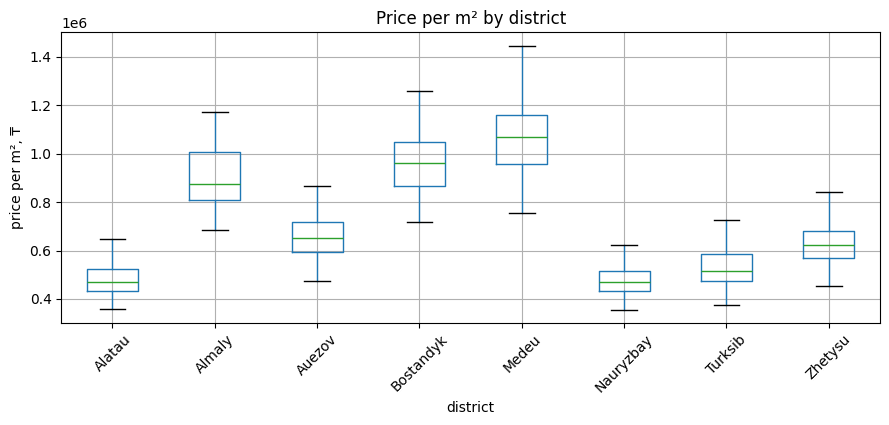

district
Alatau        469634.0
Nauryzbay     470729.0
Turksib       515543.0
Zhetysu       621237.0
Auezov        653278.0
Almaly        874327.0
Bostandyk     961168.0
Medeu        1069185.0
ratio most/least expensive district: 2.28


In [30]:
df.boxplot(column="price_per_m2", by="district", rot=45, figsize=(9, 4.5))
plt.ylabel("price per m², ₸"); plt.xlabel("district"); plt.title("Price per m² by district"); plt.suptitle("")
plt.tight_layout(); plt.show()
ppm_med = df.groupby("district")["price_per_m2"].median()
print(ppm_med.round(0).sort_values().to_string())
print(f"ratio most/least expensive district: {ppm_med.max() / ppm_med.min():.2f}")

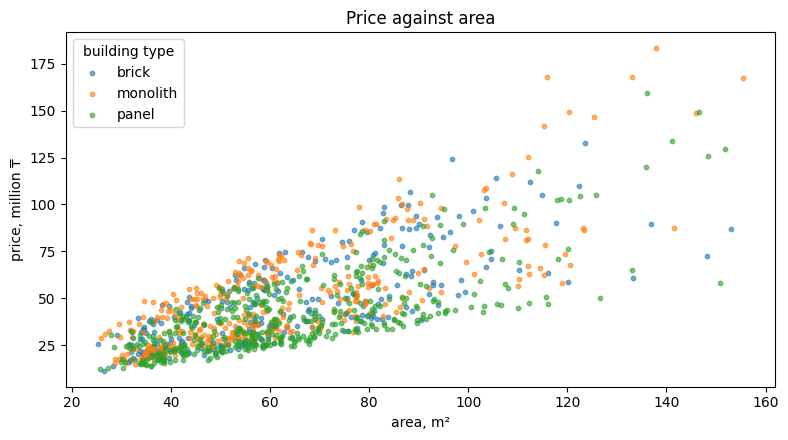

Pearson r(area, price) = 0.745


In [31]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for bt, grp in df.groupby("building_type"):
    ax.scatter(grp["area_m2"], grp["price_kzt"] / 1e6, s=10, alpha=0.6, label=bt)
ax.set_xlabel("area, m²"); ax.set_ylabel("price, million ₸"); ax.set_title("Price against area"); ax.legend(title="building type")
plt.tight_layout(); plt.show()
corr = df["area_m2"].corr(df["price_kzt"])
print(f"Pearson r(area, price) = {corr:.3f}")

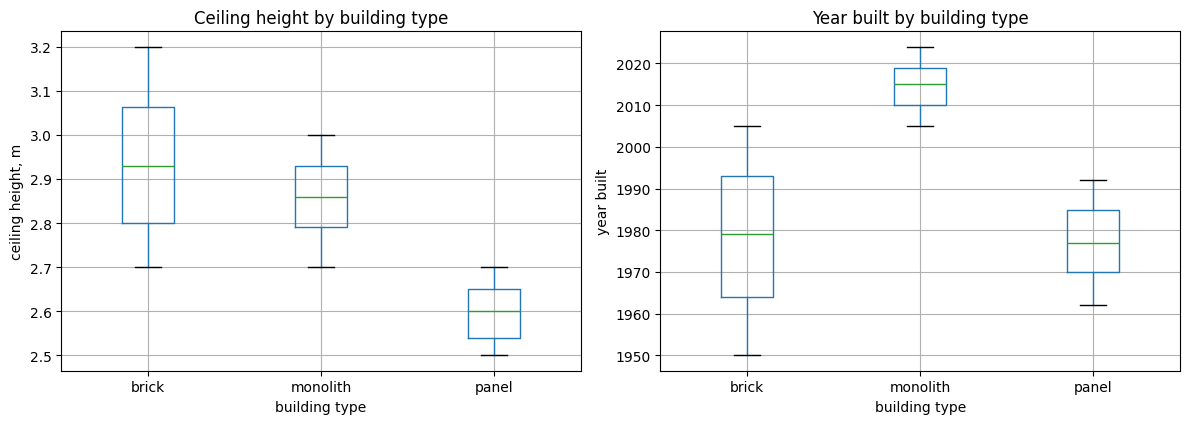

               ceiling_height_m  year_built
building_type                              
brick                      2.93      1979.0
monolith                   2.86      2015.0
panel                      2.60      1977.0


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
df.boxplot(column="ceiling_height_m", by="building_type", ax=axes[0])
axes[0].set_ylabel("ceiling height, m"); axes[0].set_xlabel("building type"); axes[0].set_title("Ceiling height by building type")
df.boxplot(column="year_built", by="building_type", ax=axes[1])
axes[1].set_ylabel("year built"); axes[1].set_xlabel("building type"); axes[1].set_title("Year built by building type")
plt.suptitle(""); plt.tight_layout(); plt.show()
print(df.groupby("building_type")[["ceiling_height_m", "year_built"]].median())

In [33]:
# observations with numbers, computed so the text always matches the data
ppm_med = df.groupby("district")["price_per_m2"].median()
bt = df.groupby("building_type")[["ceiling_height_m", "year_built"]].median()
print(f"1) Price per m²: {ppm_med.idxmax()} has the highest median ({ppm_med.max():,.0f} ₸/m²), "
      f"{ppm_med.max() / ppm_med.min():.1f}x the cheapest district {ppm_med.idxmin()} ({ppm_med.min():,.0f} ₸/m²).")
print(f"2) Price vs area: price rises almost linearly with area (Pearson r = {df['area_m2'].corr(df['price_kzt']):.2f}); "
      f"the spread at a given area comes from the district.")
print(f"3) Building type: median ceiling is {bt.loc['panel', 'ceiling_height_m']:.2f} m in panel vs "
      f"{bt.loc['brick', 'ceiling_height_m']:.2f} m in brick and {bt.loc['monolith', 'ceiling_height_m']:.2f} m in monolith buildings; "
      f"median year built panel {bt.loc['panel', 'year_built']:.0f}, brick {bt.loc['brick', 'year_built']:.0f}, monolith {bt.loc['monolith', 'year_built']:.0f}.")

1) Price per m²: Medeu has the highest median (1,069,185 ₸/m²), 2.3x the cheapest district Alatau (469,634 ₸/m²).
2) Price vs area: price rises almost linearly with area (Pearson r = 0.74); the spread at a given area comes from the district.
3) Building type: median ceiling is 2.60 m in panel vs 2.93 m in brick and 2.86 m in monolith buildings; median year built panel 1977, brick 1979, monolith 2015.


**Observations** (numbers printed above):
1. **Price per m² by district** — Medeu has the highest median price per m² (≈ 1.07 M ₸) and Alatau the lowest (≈ 0.47 M ₸), a 2.3× gap — the reason the outlier fences had to be computed per district.
2. **Price against area** — price rises with area with Pearson r = 0.74; at a given area the vertical spread is the district premium.
3. **Ceiling height / year built by building type** — panel flats have a median ceiling of 2.60 m vs 2.93 m (brick) and 2.86 m (monolith), and monolith buildings are 38 years newer (median 2015 vs 1977 for panel) — the dependence that makes the building-type median the better imputer in Step 5.

### Complete cleaning log

In [34]:
log_table = pd.DataFrame(LOG)
print(log_table.to_string(index=False))

import os
saved = pd.read_csv("data/almaty_apartments_clean.csv")
print("\ndata/almaty_apartments_clean.csv exists:", os.path.exists("data/almaty_apartments_clean.csv"), "| shape:", saved.shape,
      "| NaN still marked:", int(saved.isna().sum().sum()))

Step                                                                             Operation  Rows before  Rows after  Cells changed
  3a                                                             drop exact duplicate rows         1153        1120            363
  3a                                                         parse listed_date to datetime         1120        1120           1120
  3a                               resolve reposts: keep the latest posting per listing_id         1120        1080            440
  3b          canonicalise district spellings (strip, casefold, Latin/Cyrillic prefix map)         1080        1080            157
  3c                                   area_m2: strip 'm²', decimal comma -> dot, to float         1080        1080             88
  3c                           price_kzt: keep digits only (drop ',', spaces, '₸'), to int         1080        1080             90
  3c                                                          rooms: 'studio' -> 1,

## Step 8 · Summary and git history

| Item | Result |
|---|---|
| Sample | 90 % of listings, `random_state = YOUR_ID = 2954` → 1153 rows → 1080 listings after 3a |
| Grain | one row per `listing_id`, latest posting kept |
| Districts | 8 canonical names, 0 NaN |
| Sentinels | `floor = -1` (12), `year_built = 0` (24), `ceiling_height_m = 0` (22) → NaN |
| Impossible | `floor > total_floors` (12) → floor NaN |
| Outliers | IQR on price/m² **by district** (global: 0 flagged, by district: 11); lost-decimal areas ÷ 10; 0 flagged after the fix |
| Missing | split first; building-type medians for ceiling & year, median for floor; 0 NaN left |
| Model sanity check | test R² = 0.913 (Step 6c) |

The repository was developed on three feature branches (`step-2-4-cleaning`, `step-5-6-missing-scaling`, `step-7-8-eda-report`)
merged into `main`.

In [35]:
!git --no-pager log --oneline --graph --color=never

*   0e93a39 (HEAD -> set-student-id-2954, origin/main, main) Merge pull request #4 from Uni-courses-CSS3004-ENG-1/step-5-6-missing-scaling
|\  
| *   01889d3 (origin/step-5-6-missing-scaling) Merge pull request #3 from Uni-courses-CSS3004-ENG-1/step-7-8-eda-report
| |\  
| | * 2a3f1e8 (origin/step-7-8-eda-report, step-7-8-eda-report) Re-run notebook top to bottom; show git history without ANSI colour codes
| | * 45cb2e8 Step 8: summary table and git history cell
| | * 87c69e7 Step 7: EDA plots with numeric observations and full cleaning log
| |/  
* | 2eb7390 Merge pull request #2 from Uni-courses-CSS3004-ENG-1/step-5-6-missing-scaling
|\| 
| * b1e0372 (step-5-6-missing-scaling) Step 6: compare scalers, show scaler leakage, build final matrix (test R2 check)
| * 34527c0 Step 5: split first, diagnose MCAR/MAR, masking experiment, fill from train only
|/  
*   350e338 Merge pull request #1: Steps 2-4 inspection and cleaning
|\  
| * 71b35ee (origin/step-2-4-cleaning, step-2-4-cleaning) S